# Credit risk: modelling

Picks up from `credit_risk_clean.csv`, which still has its missing values in it because
imputation is a fitted step and belongs on this side of the split.



## 1. Load and feature groups

`loan_grade` and `loan_int_rate` are from the lender's model, so I keep them in a separate list. Every model below gets run twice, once with them and once without to compare.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder, FunctionTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, precision_recall_curve

RANDOM_STATE = 67
TARGET = "loan_status"

df = pd.read_csv("credit_risk_clean.csv")

NUMERIC = ["person_age", "person_income", "person_emp_length", "loan_amnt",
           "loan_int_rate", "loan_percent_income", "cb_person_cred_hist_length"]
CATEGORICAL = ["person_home_ownership", "loan_intent", "loan_grade",
               "cb_person_default_on_file"]
LENDER = ["loan_grade", "loan_int_rate"]

X = df[NUMERIC + CATEGORICAL]
y = df[TARGET]

print(f"{len(df):,} rows, {len(NUMERIC)} numeric + {len(CATEGORICAL)} categorical features")
print(f"default rate {y.mean():.4f}")
print(f"lender-judgement columns held separately: {LENDER}")

32,416 rows, 7 numeric + 4 categorical features
default rate 0.2187
lender-judgement columns held separately: ['loan_grade', 'loan_int_rate']


## 2. Split

The data is stratified at 0.2187 to make sure that an unlucky shuffle does not make the training data sparse with positives. There is no date/time data, so no need to consider any chronological split.

Everything after this point that learns anything from data learns it from `X_train` only.

In [2]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print(f"train {len(X_train):,} rows, default rate {y_train.mean():.4f}")
print(f"test  {len(X_test):,} rows, default rate {y_test.mean():.4f}")

assert len(X_train) == 25932 and len(X_test) == 6484
assert round(y_train.mean(), 3) == round(y_test.mean(), 3) == 0.219

train 25,932 rows, default rate 0.2187
test  6,484 rows, default rate 0.2187


## 3. Two preprocessors

Logistic regression and HGB approach NaN values in different ways. 

Logistic regression can't take a NaN and needs features on similar scales, so it gets median
imputation, an indicator column for rows that were originally blank, and a standard scaler.
`person_income` is logged first because of the long right tail. The one-hot encoder ignores
unknown categories instead of erroring, since a rare category could be missing from a CV fold.

HistGradientBoosting has no problem processing the NaN values. It decides at each split which
direction missing values should go, which is how the 31.5% default rate among blank employment
histories gets leveraged instead of being averaged away. Categoricals go through an ordinal
encoder, and I pass their column positions to the model so it treats them as categories, not
ordered numbers.

Both are functions of the feature list so the with/without runs use the same code.

In [ ]:
def lr_pipeline(num_cols, cat_cols, class_weight=None):
    skewed = [c for c in num_cols if c == "person_income"]
    plain = [c for c in num_cols if c != "person_income"]

    pre = ColumnTransformer([
        ("num", Pipeline([
            ("impute", SimpleImputer(strategy="median", add_indicator=True)),
            ("scale", StandardScaler()),
        ]), plain),
        ("skew", Pipeline([
            ("log", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
            ("impute", SimpleImputer(strategy="median")),
            ("scale", StandardScaler()),
        ]), skewed),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ])
    return Pipeline([
        ("pre", pre),
        ("model", LogisticRegression(max_iter=2000, class_weight=class_weight,
                                     random_state=RANDOM_STATE)),
    ])


def hgb_pipeline(num_cols, cat_cols, class_weight=None, **params):
    # Categoricals first so their positions after the transform are 0..len(cat_cols)-1.
    pre = ColumnTransformer([
        ("cat", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=np.nan,
                               encoded_missing_value=np.nan), cat_cols),
        ("num", "passthrough", num_cols),
    ])
    return Pipeline([
        ("pre", pre),
        ("model", HistGradientBoostingClassifier(
            categorical_features=list(range(len(cat_cols))),
            class_weight=class_weight, random_state=RANDOM_STATE, **params)),
    ])


def evaluate(pipe, name, num_cols, cat_cols):
    # Fit on train, score once on test.
    cols = num_cols + cat_cols
    pipe.fit(X_train[cols], y_train)
    proba = pipe.predict_proba(X_test[cols])[:, 1]
    return {
        "model": name,
        "roc_auc": roc_auc_score(y_test, proba),
        "pr_auc": average_precision_score(y_test, proba),
        "_proba": proba,
        "_fitted": pipe,
    }

print("preprocessing built; nothing fitted yet")

preprocessing built; nothing fitted yet


## 4. Logistic regression baseline

This is the number everything else gets measured against. Nothing is tuned here, and the
full feature set including the lender columns is used, so this is the most generous version
of the simplest model.

In [4]:
results = []

baseline = evaluate(lr_pipeline(NUMERIC, CATEGORICAL), "Logistic regression (baseline)",
                    NUMERIC, CATEGORICAL)
results.append(baseline)

print(f"AUC-ROC  {baseline['roc_auc']:.4f}")
print(f"PR-AUC   {baseline['pr_auc']:.4f}   (floor is the base rate, {y_test.mean():.4f})")

AUC-ROC  0.8785
PR-AUC   0.7331   (floor is the base rate, 0.2187)


## 5. Class imbalance

21.9% of loans default. I tried `class_weight="balanced"`, which weights each class by inverse
frequency so the 5,671 training defaults count as much in total as the 20,261 repayments.

I went with this over SMOTE since it doesn't create synthetic rows and it sits inside the
model, so it gets reapplied in every CV fold automatically. SMOTE done before the split, or on
a validation fold, leaks.

Ran it both ways below.

In [5]:
unweighted = evaluate(lr_pipeline(NUMERIC, CATEGORICAL, class_weight=None),
                      "Logistic regression (no class weight)", NUMERIC, CATEGORICAL)

print(f"{'':34} {'AUC-ROC':>8} {'PR-AUC':>8}")
for r in (unweighted, baseline):
    print(f"{r['model']:34} {r['roc_auc']:8.4f} {r['pr_auc']:8.4f}")

print(f"\nclass counts in train: {dict(y_train.value_counts())}")

                                    AUC-ROC   PR-AUC
Logistic regression (no class weight)   0.8776   0.7434
Logistic regression (baseline)       0.8785   0.7331

class counts in train: {0: np.int64(20261), 1: np.int64(5671)}


Balancing barely changed AUC-ROC (0.8785 vs 0.8776) and lowered PR-AUC (0.7331 vs 0.7434
without it). Both metrics only look at how predictions are ranked, and reweighting mostly
shifts the probabilities up without changing their order much, so this makes sense.

It does change the probabilities themselves. The balanced model is trained as if defaults were
half the data, so its average prediction runs above the real 21.9% rate. That matters for the
threshold in section 9, since the cost calculation uses the probabilities directly.

## 6. HistGradientBoosting, tuned without touching test

Hyperparameters are picked with 5-fold cross-validation on the training set. Each fold refits
the whole pipeline, encoder included, so nothing is learned from the fold being scored.

Scored on `average_precision` (PR-AUC). Tuning on accuracy would favour models that just
predict "no default" more often.

The test set is not involved in any of this, only the training set.

In [6]:
param_grid = {
    "model__learning_rate": [0.05, 0.1],
    "model__max_leaf_nodes": [15, 31],
    "model__max_iter": [100, 300],
}

search = GridSearchCV(
    hgb_pipeline(NUMERIC, CATEGORICAL),
    param_grid,
    scoring="average_precision",
    cv=5,
    n_jobs=-1,
)
search.fit(X_train[NUMERIC + CATEGORICAL], y_train)

print("best params:")
for k, v in search.best_params_.items():
    print(f"  {k.replace('model__', '')}: {v}")
print(f"\nbest cross-validated PR-AUC on train: {search.best_score_:.4f}")

best params:
  learning_rate: 0.05
  max_iter: 300
  max_leaf_nodes: 31

best cross-validated PR-AUC on train: 0.8974


In [7]:
best_params = {k.replace("model__", ""): v for k, v in search.best_params_.items()}

hgb = evaluate(hgb_pipeline(NUMERIC, CATEGORICAL, **best_params),
               "HistGradientBoosting", NUMERIC, CATEGORICAL)
results.append(hgb)

print(f"{'':34} {'AUC-ROC':>8} {'PR-AUC':>8}")
for r in (baseline, hgb):
    print(f"{r['model']:34} {r['roc_auc']:8.4f} {r['pr_auc']:8.4f}")

lift = hgb["pr_auc"] - baseline["pr_auc"]
print(f"\nPR-AUC gain over the baseline: {lift:+.4f}")

                                    AUC-ROC   PR-AUC
Logistic regression (baseline)       0.8785   0.7331
HistGradientBoosting                 0.9466   0.9045

PR-AUC gain over the baseline: +0.1714


## 7. With and without the lender's judgement

The lender assigns `loan_grade` and `loan_int_rate` after assessing the application, so using
them partly means predicting the lender's own model. Dropping both leaves the applicant's info
and credit history.

Both models, both ways.

In [8]:
NUM_NO_LENDER = [c for c in NUMERIC if c not in LENDER]
CAT_NO_LENDER = [c for c in CATEGORICAL if c not in LENDER]
print(f"dropped {LENDER}, leaving {len(NUM_NO_LENDER) + len(CAT_NO_LENDER)} features")

lr_no = evaluate(lr_pipeline(NUM_NO_LENDER, CAT_NO_LENDER),
                 "Logistic regression", NUM_NO_LENDER, CAT_NO_LENDER)

search_no = GridSearchCV(hgb_pipeline(NUM_NO_LENDER, CAT_NO_LENDER), param_grid,
                         scoring="average_precision", cv=5, n_jobs=-1)
search_no.fit(X_train[NUM_NO_LENDER + CAT_NO_LENDER], y_train)
best_no = {k.replace("model__", ""): v for k, v in search_no.best_params_.items()}

hgb_no = evaluate(hgb_pipeline(NUM_NO_LENDER, CAT_NO_LENDER, **best_no),
                  "HistGradientBoosting", NUM_NO_LENDER, CAT_NO_LENDER)

print("done")

dropped ['loan_grade', 'loan_int_rate'], leaving 9 features


done


In [9]:
rows = [
    ("Logistic regression", baseline, lr_no),
    ("HistGradientBoosting", hgb, hgb_no),
]

print(f"{'':22} {'with lender cols':>26}    {'without':>18}")
print(f"{'':22} {'AUC-ROC':>12} {'PR-AUC':>13}    {'AUC-ROC':>8} {'PR-AUC':>9}")
for name, w, wo in rows:
    print(f"{name:22} {w['roc_auc']:12.4f} {w['pr_auc']:13.4f}    "
          f"{wo['roc_auc']:8.4f} {wo['pr_auc']:9.4f}")

print()
for name, w, wo in rows:
    print(f"{name}: dropping the lender columns costs "
          f"{w['roc_auc'] - wo['roc_auc']:.4f} AUC-ROC and "
          f"{w['pr_auc'] - wo['pr_auc']:.4f} PR-AUC")

                                 with lender cols               without
                            AUC-ROC        PR-AUC     AUC-ROC    PR-AUC
Logistic regression          0.8785        0.7331      0.8205    0.6376
HistGradientBoosting         0.9466        0.9045      0.8997    0.8119

Logistic regression: dropping the lender columns costs 0.0579 AUC-ROC and 0.0955 PR-AUC
HistGradientBoosting: dropping the lender columns costs 0.0469 AUC-ROC and 0.0926 PR-AUC


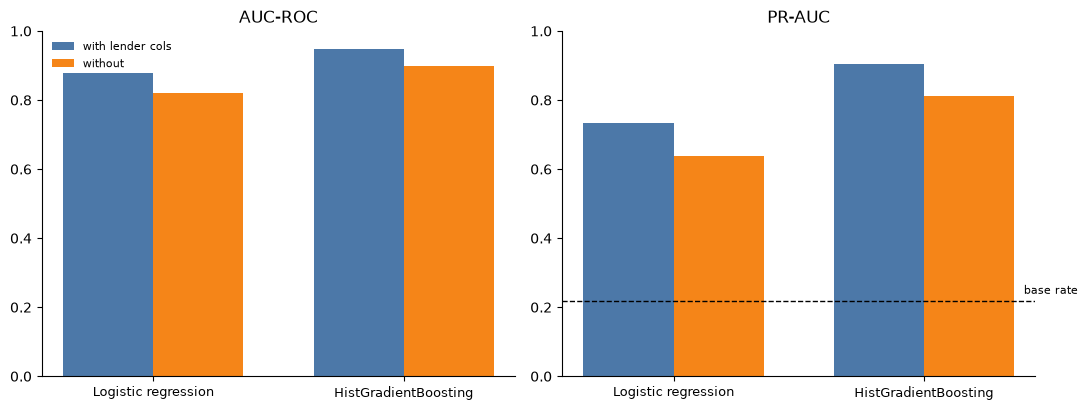

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

for ax, (key, label) in zip(axes, [("roc_auc", "AUC-ROC"), ("pr_auc", "PR-AUC")]):
    names = [n for n, _, _ in rows]
    xs = np.arange(len(names))
    ax.bar(xs - 0.18, [w[key] for _, w, _ in rows], 0.36, label="with lender cols",
           color="#4C78A8")
    ax.bar(xs + 0.18, [wo[key] for _, _, wo in rows], 0.36, label="without",
           color="#F58518")
    ax.set_xticks(xs, names, fontsize=9)
    ax.set_title(label)
    ax.set_ylim(0, 1)
    ax.spines[["top", "right"]].set_visible(False)
    if key == "pr_auc":
        ax.axhline(y_test.mean(), ls="--", lw=1, color="black")
        ax.text(1.4, y_test.mean() + 0.02, "base rate", fontsize=8)
axes[0].legend(fontsize=8, frameon=False)
plt.tight_layout()
plt.show()

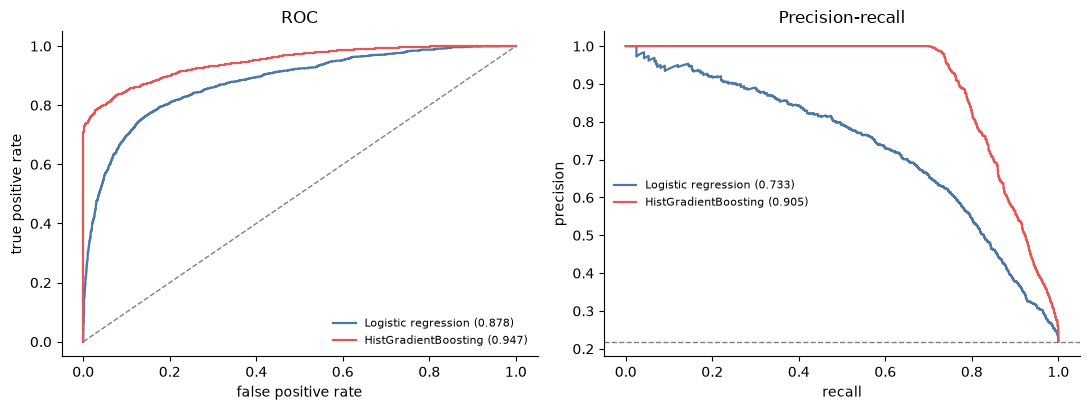

In [11]:
# ROC and PR curves for the two headline models.
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

for r, color in [(baseline, "#4C78A8"), (hgb, "#E45756")]:
    fpr, tpr, _ = roc_curve(y_test, r["_proba"])
    axes[0].plot(fpr, tpr, color=color, lw=1.6,
                 label=f"{r['model'].split(' (')[0]} ({r['roc_auc']:.3f})")
    prec, rec, _ = precision_recall_curve(y_test, r["_proba"])
    axes[1].plot(rec, prec, color=color, lw=1.6,
                 label=f"{r['model'].split(' (')[0]} ({r['pr_auc']:.3f})")

axes[0].plot([0, 1], [0, 1], ls="--", lw=1, color="grey")
axes[0].set_xlabel("false positive rate"); axes[0].set_ylabel("true positive rate")
axes[0].set_title("ROC")
axes[1].axhline(y_test.mean(), ls="--", lw=1, color="grey")
axes[1].set_xlabel("recall"); axes[1].set_ylabel("precision")
axes[1].set_title("Precision-recall")
for ax in axes:
    ax.legend(fontsize=8, frameon=False)
    ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## 8. What drives the predictions

For logistic regression I use the coefficients. Exponentiated, each one is an odds ratio: how
much the odds of default multiply for a one standard deviation increase in a numeric feature,
or for being in a given category. Above 1 raises risk, below 1 lowers it.

HGB has no coefficients, so I use SHAP, which gives each feature a signed contribution to each
prediction. Averaging the absolute values ranks features by how much the model relies on them.

In [12]:
lr_fitted = baseline["_fitted"]
feature_names = lr_fitted.named_steps["pre"].get_feature_names_out()
coefs = lr_fitted.named_steps["model"].coef_[0]

coef_tbl = (pd.DataFrame({"feature": feature_names, "coef": coefs})
              .assign(odds_ratio=lambda d: np.exp(d["coef"]),
                      abs_coef=lambda d: d["coef"].abs())
              .sort_values("abs_coef", ascending=False)
              .head(15)
              .drop(columns="abs_coef"))

print("Top 15 logistic regression coefficients (standardised features)")
print(coef_tbl.to_string(index=False, float_format=lambda v: f"{v:8.4f}"))

Top 15 logistic regression coefficients (standardised features)
                           feature     coef  odds_ratio
                 cat__loan_grade_G   2.6361     13.9580
                 cat__loan_grade_A  -1.9580      0.1411
                 cat__loan_grade_B  -1.7296      0.1773
                 cat__loan_grade_C  -1.4407      0.2368
    cat__person_home_ownership_OWN  -1.4332      0.2386
                 cat__loan_grade_F   1.2256      3.4061
   cat__person_home_ownership_RENT   0.8884      2.4313
                 cat__loan_grade_E   0.8644      2.3737
          num__loan_percent_income   0.8251      2.2822
          cat__loan_intent_VENTURE  -0.6755      0.5089
               skew__person_income  -0.6325      0.5313
  cat__loan_intent_HOMEIMPROVEMENT   0.6302      1.8780
                 cat__loan_grade_D   0.5671      1.7632
  cat__person_home_ownership_OTHER   0.3952      1.4847
cat__loan_intent_DEBTCONSOLIDATION   0.3943      1.4833


In [13]:
import shap

hgb_fitted = hgb["_fitted"]
pre = hgb_fitted.named_steps["pre"]
model = hgb_fitted.named_steps["model"]

hgb_feature_names = CATEGORICAL + NUMERIC          # ColumnTransformer order: cat then num
sample = X_test[NUMERIC + CATEGORICAL].sample(1000, random_state=RANDOM_STATE)
X_sample = pd.DataFrame(pre.transform(sample), columns=hgb_feature_names)

try:
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_sample)
    method = "TreeExplainer"
except Exception as exc:                            # noqa: BLE001
    print(f"TreeExplainer unavailable ({type(exc).__name__}), falling back")
    background = shap.sample(
        pd.DataFrame(pre.transform(X_train[NUMERIC + CATEGORICAL].sample(200, random_state=RANDOM_STATE)),
                     columns=hgb_feature_names), 100, random_state=RANDOM_STATE)
    explainer = shap.Explainer(model.predict_proba, background)
    shap_values = explainer(X_sample).values[..., 1]
    method = "Explainer fallback"

print(f"{method}: shap values shape {np.asarray(shap_values).shape}")

/home/taidd/personal-projects/credit-risk-ml/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


TreeExplainer: shap values shape (1000, 11)


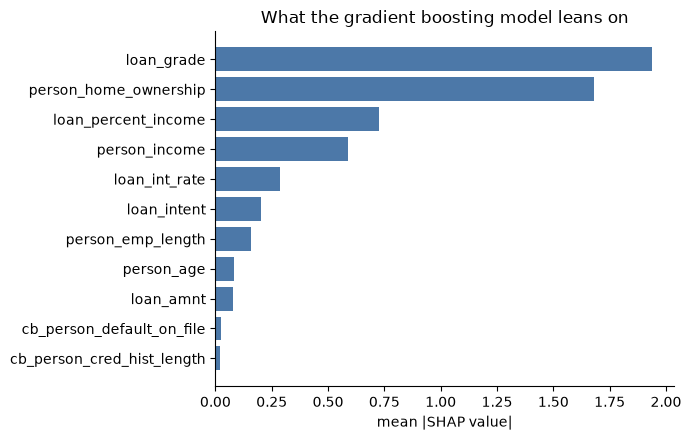

loan_grade                   1.9393
person_home_ownership        1.6821
loan_percent_income          0.7264
person_income                0.5893
loan_int_rate                0.2857
loan_intent                  0.2029
person_emp_length            0.1602
person_age                   0.0822
loan_amnt                    0.0801
cb_person_default_on_file    0.0258
cb_person_cred_hist_length   0.0209


In [14]:
sv = np.asarray(shap_values)
if sv.ndim == 3:                                    # (n, features, classes)
    sv = sv[..., 1]

mean_abs = pd.Series(np.abs(sv).mean(axis=0), index=hgb_feature_names).sort_values()

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.barh(mean_abs.index, mean_abs.values, color="#4C78A8")
ax.set_xlabel("mean |SHAP value|")
ax.set_title("What the gradient boosting model leans on")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

print(mean_abs.sort_values(ascending=False).to_string(float_format=lambda v: f"{v:.4f}"))

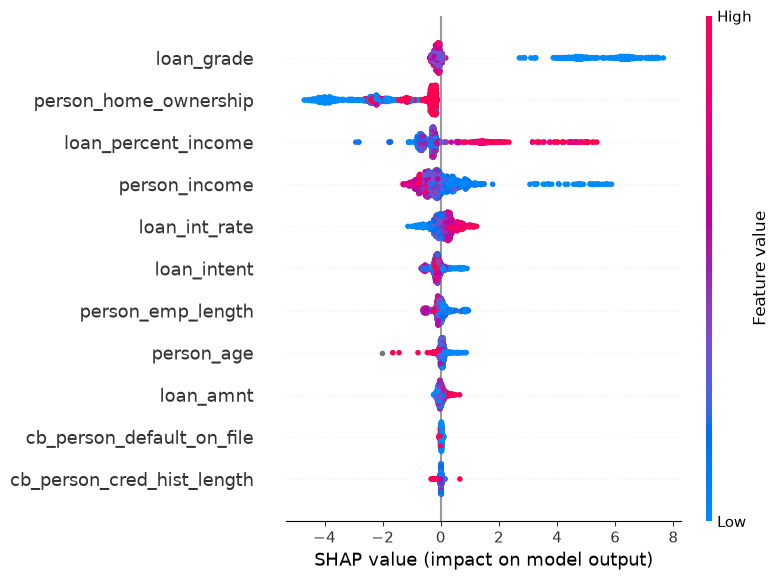

In [15]:
shap.summary_plot(sv, X_sample, feature_names=hgb_feature_names, show=False, max_display=11)
plt.tight_layout()
plt.show()

## 9. Cost-based threshold

The cost matrix and the approve/decline threshold are mine to write, so this notebook stops
here and hands over the pieces.

Every model above returns a probability of default. Turning that into an approve or decline
is a business decision: a false negative is a loan that defaults, a false positive is a good
customer turned away, and the two do not cost the same. The 0.5 default assumes they do.

One thing to settle before writing that analysis. Class weighting and a cost matrix are two
ways of expressing the same asymmetry, so applying both double-counts it, and the balanced
model's probabilities are shifted away from the base rate in a way a cost calculation will
read at face value. So I save both sets: the balanced model's probabilities, and the same
model refit without weighting, whose probabilities are closer to calibrated. The comparison
of mean predicted probability against the actual default rate below shows the size of the
gap.

In [16]:
best = max(results, key=lambda r: r["pr_auc"])

# Same model and hyperparameters, no class weighting, for probabilities that can be
# read as probabilities. Which set to threshold on is a decision for the cost analysis.
calibrated = evaluate(hgb_pipeline(NUMERIC, CATEGORICAL, class_weight=None, **best_params),
                      "HistGradientBoosting (no class weight)", NUMERIC, CATEGORICAL)

np.savez("preds.npz",
         y_test=y_test.to_numpy(),
         y_proba=best["_proba"],
         y_proba_unweighted=calibrated["_proba"],
         model_name=np.array(best["model"]))

print(f"saved preds.npz  ({best['model']}, {len(y_test):,} test rows)\n")
print(f"{'':26} {'AUC-ROC':>8} {'PR-AUC':>8} {'mean p':>8}")
for label, r in [("class_weight=balanced", best), ("no class weight", calibrated)]:
    print(f"{label:26} {r['roc_auc']:8.4f} {r['pr_auc']:8.4f} {r['_proba'].mean():8.4f}")
print(f"{'actual default rate':26} {'':8} {'':8} {y_test.mean():8.4f}")

print("\nload with:  d = np.load('preds.npz')")
print("  d['y_test']              true labels")
print("  d['y_proba']             balanced model")
print("  d['y_proba_unweighted']  unweighted, closer to calibrated")

saved preds.npz  (HistGradientBoosting, 6,484 test rows)

                            AUC-ROC   PR-AUC   mean p
class_weight=balanced        0.9466   0.9045   0.3100
no class weight              0.9483   0.9072   0.2208
actual default rate                            0.2187

load with:  d = np.load('preds.npz')
  d['y_test']              true labels
  d['y_proba']             balanced model
  d['y_proba_unweighted']  unweighted, closer to calibrated


## 10. Where this leaves things

HGB beats the baseline by a wide margin, with and without the lender columns. Tuning only used
the training set, and each model was scored on test once.

Left to do: the cost-based threshold, then the README. Limitations to cover there: the 740 rows
with implausible employment lengths that I kept in notebook 1, and the lack of a time column,
so there's no way to check how this holds up on future applicants.